In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/food_delivery_dataset.csv')

In [ ]:
df.head()

,order_id,restaurant_id,food_item,order_time,delivery_time,delivery_distance,order_value,delivery_method,traffic_condition,weather_condition,...,food_temperature,food_freshness,packaging_quality,food_condition,customer_satisfaction,small_route,bike_friendly_route,route_type,route_efficiency,traffic_avoidance
0,ORD000001,16,Taccos,2024-01-31,2024-01-31,2.17,42.21,Bike,Medium,Snowy,...,Hot,5,1,Fair,3,False,False,Bike-friendly,0.801291,Yes
1,ORD000002,30,Briyani rice,2024-10-16,2024-10-16,13.40,24.82,Car,High,Sunny,...,Warm,3,2,Fair,5,False,False,Bike-friendly,0.645795,No
2,ORD000003,3,Pasta,2024-09-11,2024-09-11,10.74,37.25,Walk,High,Snowy,...,Warm,4,5,Good,5,True,False,Bike-friendly,0.291193,No
3,ORD000004,93,Whole cake,2024-09-17,2024-09-17,6.29,49.88,Bike,High,Snowy,...,Cold,2,3,Poor,4,False,False,Car-only,0.133827,No
4,ORD000005,15,Sushi,2024-08-26,2024-08-26,2.94,8.53,Walk,Low,Sunny,...,Cold,4,5,Good,1,False,True,Car-only,0.349233,No


In [ ]:
df.size

620000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               20000 non-null  object 
 1   restaurant_id          20000 non-null  int64  
 2   food_item              20000 non-null  object 
 3   order_time             20000 non-null  object 
 4   delivery_time          20000 non-null  object 
 5   delivery_distance      20000 non-null  float64
 6   order_value            20000 non-null  float64
 7   delivery_method        20000 non-null  object 
 8   traffic_condition      20000 non-null  object 
 9   weather_condition      20000 non-null  object 
 10  delivery_delay         20000 non-null  float64
 11  route_taken            20000 non-null  object 
 12  customer_id            20000 non-null  object 
 13  age                    20000 non-null  int64  
 14  gender                 20000 non-null  object 
 15  lo

In [ ]:
df.describe()

,restaurant_id,delivery_distance,order_value,delivery_delay,age,order_history,customer_rating,food_freshness,packaging_quality,customer_satisfaction,route_efficiency
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,50.528000,8.498350,27.335090,4.952421,38.925300,25.751400,3.026800,2.991700,3.003400,2.976300,0.496246
std,28.715004,3.768308,13.026475,8.624563,12.370941,14.311731,1.416468,1.415744,1.416929,1.415217,0.287044
min,1.000000,2.000000,5.000000,-10.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000276
25%,26.000000,5.220000,15.960000,-2.430000,28.000000,13.000000,2.000000,2.000000,2.000000,2.000000,0.245070
50%,51.000000,8.470000,27.200000,4.900000,39.000000,26.000000,3.000000,3.000000,3.000000,3.000000,0.494741
75%,75.000000,11.810000,38.712500,12.320000,50.000000,38.000000,4.000000,4.000000,4.000000,4.000000,0.742996
max,100.000000,15.000000,49.990000,20.000000,60.000000,50.000000,5.000000,5.000000,5.000000,5.000000,0.999841


In [ ]:
df.isnull().sum()

,0
order_id,0
restaurant_id,0
food_item,0
order_time,0
delivery_time,0
delivery_distance,0
order_value,0
delivery_method,0
traffic_condition,0
weather_condition,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['order_time'] = pd.to_datetime(df['order_time'])
df['delivery_time'] = pd.to_datetime(df['delivery_time'])

In [ ]:
df['month'] = df['order_time'].dt.month_name()

In [ ]:
df['day'] = df['order_time'].dt.day_name()

In [ ]:
df['food_item'].value_counts().head(10)

,count
food_item,
Pasta,1884
Whole cake,958
Soup,948
Cup cake,944
Chicken rice,934
Beef pie,934
Cookie,930
CoffeeBoba tea,922
Chicken wings,918


<Axes: xlabel='food_item'>

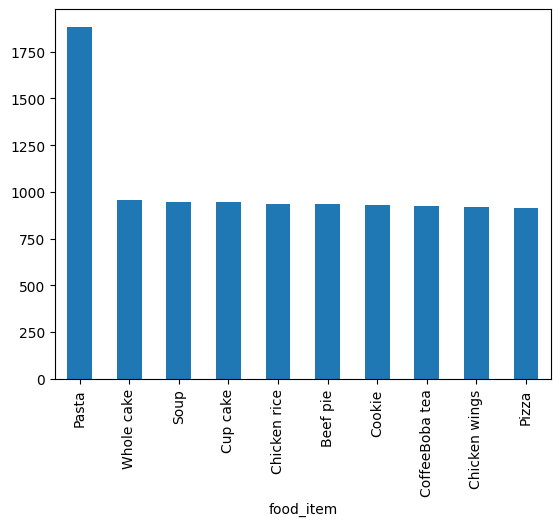

In [ ]:
df['food_item'].value_counts().head(10).plot(kind='bar')

In [ ]:
df['order_value'].mean()

np.float64(27.33509)

In [ ]:
df.groupby('traffic_condition')['delivery_delay'].mean()

,delivery_delay
traffic_condition,
High,4.980852
Low,5.051725
Medium,4.824349


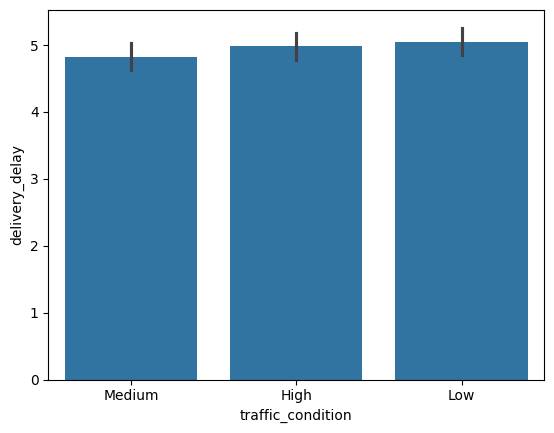

In [ ]:
sns.barplot(x='traffic_condition', y='delivery_delay', data=df)
plt.show()

In [ ]:
df.groupby('weather_condition')['delivery_delay'].mean()

,delivery_delay
weather_condition,
Rainy,4.872745
Snowy,4.950746
Sunny,5.032926


In [ ]:
df['delivery_method'].value_counts()

,count
delivery_method,
Walk,6830
Bike,6598
Car,6572


<Axes: ylabel='count'>

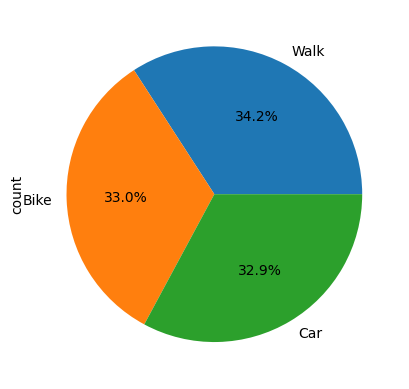

In [ ]:
df['delivery_method'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [ ]:
df['customer_satisfaction'].mean()

np.float64(2.9763)

<Axes: xlabel='delivery_delay', ylabel='customer_satisfaction'>

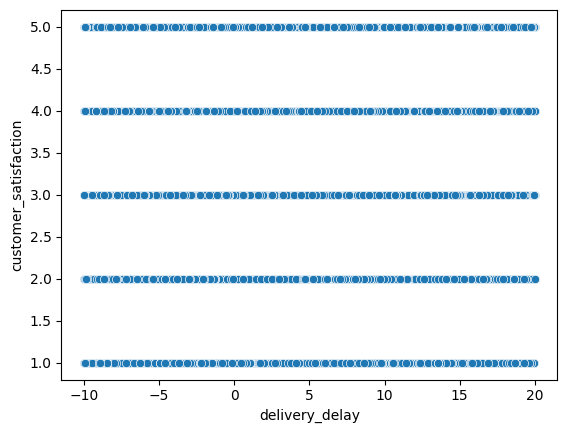

In [ ]:
sns.scatterplot(
    x='delivery_delay',
    y='customer_satisfaction',
    data=df
)

In [ ]:
df.groupby('route_type')['route_efficiency'].mean()

,route_efficiency
route_type,
Bike-friendly,0.500521
Car-only,0.488170
Mixed,0.499932


In [ ]:
df.groupby('food_item')['order_value'].mean().sort_values(ascending=False)

,order_value
food_item,
Fried chicken,28.343311
Shawarma,27.922883
Cup cake,27.921886
Pizza,27.899105
Pasta,27.717580
Chicken rice,27.690000
CoffeeBoba tea,27.648742
Chicken pie,27.422505
Cookie,27.347699


In [ ]:
df.groupby('loyalty_program')['customer_satisfaction'].mean()

,customer_satisfaction
loyalty_program,
No,2.988181
Yes,2.964457


In [ ]:
df["delivery_distance"]=pd.to_numeric(df["delivery_distance"])

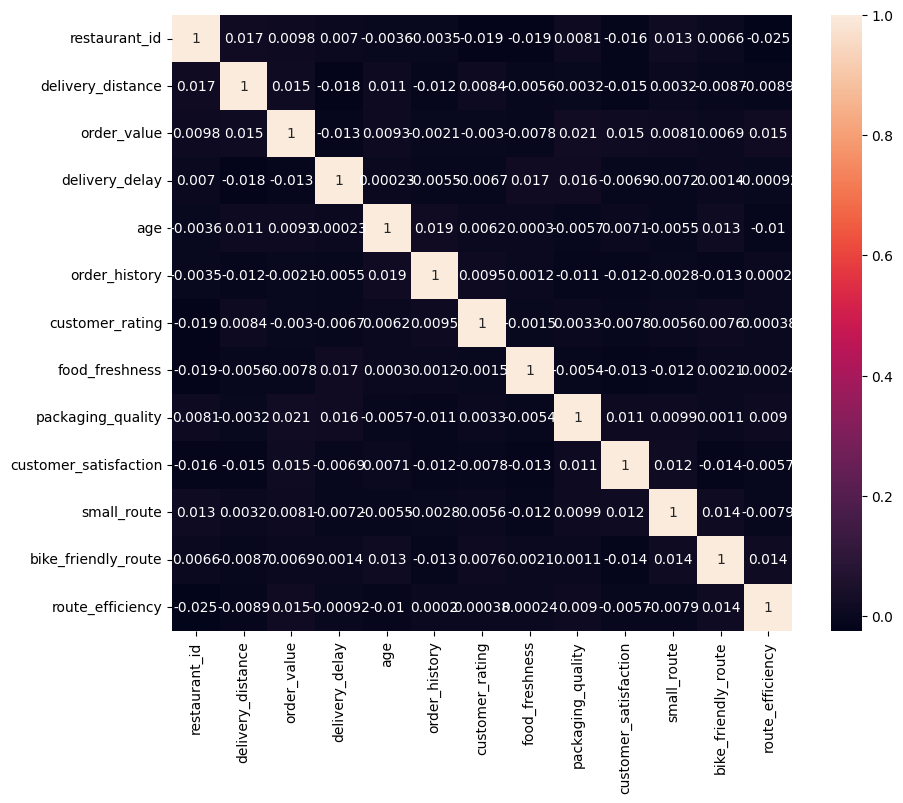

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
df.to_csv('cleaned_food_delivery_dataset.csv', index=False)

In [ ]:
import sqlite3
import pandas as pd

In [ ]:
conn = sqlite3.connect('food_delivery.db')

In [ ]:
df = pd.read_csv('cleaned_food_delivery_dataset.csv')

df.to_sql(
    'food_delivery',
    conn,
    if_exists='replace',
    index=False
)

20000

In [ ]:
query = """
SELECT *
FROM food_delivery
LIMIT 5
"""

pd.read_sql(query, conn)

,order_id,restaurant_id,food_item,order_time,delivery_time,delivery_distance,order_value,delivery_method,traffic_condition,weather_condition,...,packaging_quality,food_condition,customer_satisfaction,small_route,bike_friendly_route,route_type,route_efficiency,traffic_avoidance,month,day
0,ORD000001,16,Taccos,2024-01-31,2024-01-31,2.17,42.21,Bike,Medium,Snowy,...,1,Fair,3,0,0,Bike-friendly,0.801291,Yes,January,Wednesday
1,ORD000002,30,Briyani rice,2024-10-16,2024-10-16,13.40,24.82,Car,High,Sunny,...,2,Fair,5,0,0,Bike-friendly,0.645795,No,October,Wednesday
2,ORD000003,3,Pasta,2024-09-11,2024-09-11,10.74,37.25,Walk,High,Snowy,...,5,Good,5,1,0,Bike-friendly,0.291193,No,September,Wednesday
3,ORD000004,93,Whole cake,2024-09-17,2024-09-17,6.29,49.88,Bike,High,Snowy,...,3,Poor,4,0,0,Car-only,0.133827,No,September,Tuesday
4,ORD000005,15,Sushi,2024-08-26,2024-08-26,2.94,8.53,Walk,Low,Sunny,...,5,Good,1,0,1,Car-only,0.349233,No,August,Monday


In [ ]:
query = """
SELECT food_item,
       COUNT(*) AS total_orders
FROM food_delivery
GROUP BY food_item
ORDER BY total_orders DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,food_item,total_orders
0,Pasta,1884
1,Whole cake,958
2,Soup,948
3,Cup cake,944
4,Chicken rice,934
5,Beef pie,934
6,Cookie,930
7,CoffeeBoba tea,922
8,Chicken wings,918
9,Pizza,916


In [ ]:
query = """
SELECT food_item,
       SUM(order_value) AS revenue
FROM food_delivery
GROUP BY food_item
ORDER BY revenue DESC
"""

pd.read_sql(query, conn)

,food_item,revenue
0,Pasta,52219.92
1,Cup cake,26358.26
2,Chicken rice,25862.46
3,Whole cake,25825.66
4,Pizza,25555.58
5,CoffeeBoba tea,25492.14
6,Beef pie,25457.70
7,Cookie,25433.36
8,Soup,25428.30
9,Fried chicken,25338.92


In [ ]:
query = """
SELECT traffic_condition,
       AVG(delivery_delay) AS avg_delay
FROM food_delivery
GROUP BY traffic_condition
"""

pd.read_sql(query, conn)

,traffic_condition,avg_delay
0,High,4.980852
1,Low,5.051725
2,Medium,4.824349


In [ ]:
query = """
SELECT customer_satisfaction,
       COUNT(*) AS total_customers
FROM food_delivery
GROUP BY customer_satisfaction
"""

pd.read_sql(query, conn)

,customer_satisfaction,total_customers
0,1,4132
1,2,3970
2,3,4042
3,4,3952
4,5,3904
